In [1]:
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.distributions import Categorical

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

import importlib

In [2]:
from data_handling import read_data, process_timestamp, get_min_since, transforms
import network_builds
import supp_funcs
import data_builder
import environments
import model_trainers
import plotter

In [3]:
plt.rcParams['figure.figsize'] = [20, 10]

In [4]:
###data for a single actor###

In [5]:
data = read_data('FB')
min_since = get_min_since(data)
data_df = process_timestamp(data, min_since)

In [6]:
t = transforms(data_df)
t.all_transforms()
#t.suplemental_factors()

In [7]:
data_df = t.transformed

In [8]:
test_shape = int(0.05*data_df.shape[0])
train_shape = data_df.shape[0] - test_shape

In [9]:
train, test = data_df[:train_shape], data_df[train_shape:]

In [10]:
###data for  multiple actors###

In [231]:
bd = data_builder.build_datas()

In [340]:
### if need be to reload a module after updates
importlib.reload(network_builds)
importlib.reload(supp_funcs)
importlib.reload(model_trainers)
importlib.reload(environments)

<module 'environments' from '/Users/tyler/Desktop/investin/RL/environments.py'>

In [341]:
###train with single actor###

In [342]:
###default environment parameters
parameters = {
    'reward_type' : 'basic_trade_penalty',
    'discrete' : False,
    'action_dim' : 2,
    'initial_cash' : 10000.0,
    'running_trades_bool' : True,
    'delta_to_trade' : 0.25,
    'running_trades_freq' : 0.2,
    'c_log' : 0.0025,
    'c' : 0.35,
    ###these are for the actor class
    'lr' : 3e-4,
    'num_steps' : 300,
    'mini_batch_size' : 60,
    'ppo_epochs' : 6,
    'key' : 'MSFT',
    'action_dim' : 2,
    'seq_len' : 1,
    'params_actors' : {'MSFT':3, 'AAPL' : 1, 'AMZN': 1, 'FB':1, 'GOOG':1, 'TSLA':1},
    'type_' : 'linear',
    ###these are for the networks
    'dropout' : False,
    'discrete' : False,
    'std' : 0.0,
    'hidden_dim' : 20,
    'dim_1' : 64,
    'dim_2' : 32,
    ###these for the evolution method
    'prob_of_mutation' : 0.05,
    'percent_mutate' : 0.05,
    'breed_method' : 'crossover',
    'sigma' : 0.05

} 

In [269]:
envs = environments.environment(train, t.scaler.mean_, t.scaler.var_, params = parameters)

In [270]:
trainer = model_trainers.trainer_tester(envs, params = parameters)

In [260]:
trainer.train(1)

AttributeError: 'Tensor' object has no attribute 'saved_tensors'

In [ ]:
envs_test = environments.environment(test, t.scaler.mean_, t.scaler.var_, params = parameters)

In [ ]:
trainer.test(envs_test)

In [ ]:
###plots for single actor

In [ ]:
p = plotter.plotter(trainer, envs, envs_test)

In [ ]:
p.plot_rewards()
p.plot_rewards(test = True)
p.plot_signals()
p.plot_signals(test = True)
p.plot_monies()
p.plot_monies(test = True)
p.plot_profits()
p.plot_profits(test = True)
p.plot_trades()
p.plot_trades(test = True)
p.plot_comparison()
p.plot_actions()

In [ ]:
###train with multiple actors###

In [343]:
#multi_t = model_trainers.trainer_tester_multiple(bd)
multi_t = model_trainers.trainer_tester_multiple_envolve(bd, params = parameters)

In [344]:
#envs_baseline = environment(data_df, t.scaler.mean_, t.scaler.var_, action_dim=2, discrete=False)
#multi_t.baseline(envs_baseline)

In [345]:
multi_t.train()

pushing network update
pushing network update
pushing network update
5.749473549869185% done.
pushing network update
pushing network update
pushing network update
11.492565886031523% done.
pushing network update
pushing network update
pushing network update
17.235658222193862% done.
pushing network update
pushing network update
pushing network update
22.9787505583562% done.
pushing network update
pushing network update
pushing network update
28.72184289451854% done.
pushing network update
pushing network update
pushing network update
34.46493523068088% done.
pushing network update
pushing network update
pushing network update
40.208027566843214% done.
pushing network update
pushing network update
pushing network update
45.95111990300555% done.
pushing network update
pushing network update
pushing network update
51.69421223916789% done.
pushing network update
pushing network update
pushing network update
57.43730457533023% done.
pushing network update
pushing network update
pushing netw

In [346]:
multi_t.rewards_all

[tensor([[9999.2695]]),
 tensor([[10002.1904]]),
 tensor([[10003.6543]]),
 tensor([[10008.0850]]),
 tensor([[10009.5332]]),
 tensor([[10011.2910]]),
 tensor([[10011.2676]]),
 tensor([[10011.2988]]),
 tensor([[10011.2109]]),
 tensor([[10011.0098]]),
 tensor([[10010.3350]]),
 tensor([[10013.1230]]),
 tensor([[10013.2031]]),
 tensor([[10013.0234]]),
 tensor([[10011.9658]]),
 tensor([[10010.4570]]),
 tensor([[10021.1846]]),
 tensor([[10021.1211]]),
 tensor([[10021.6318]]),
 tensor([[10021.9502]]),
 tensor([[10021.7305]]),
 tensor([[10022.5312]]),
 tensor([[10022.7529]]),
 tensor([[10023.4980]]),
 tensor([[10023.2773]]),
 tensor([[10022.2988]]),
 tensor([[10030.5918]]),
 tensor([[10030.7109]]),
 tensor([[10032.1387]]),
 tensor([[10032.6748]]),
 tensor([[10032.3594]]),
 tensor([[10032.4268]]),
 tensor([[10032.2100]]),
 tensor([[10031.8604]]),
 tensor([[10031.8105]]),
 tensor([[10030.7305]]),
 tensor([[10035.3779]]),
 tensor([[10035.2139]]),
 tensor([[10035.1729]]),
 tensor([[10034.8457]]),
 

In [347]:
###plots for multiple actors###

In [348]:
p = plotter.plotter(multi_t, multi_t.envs, None)

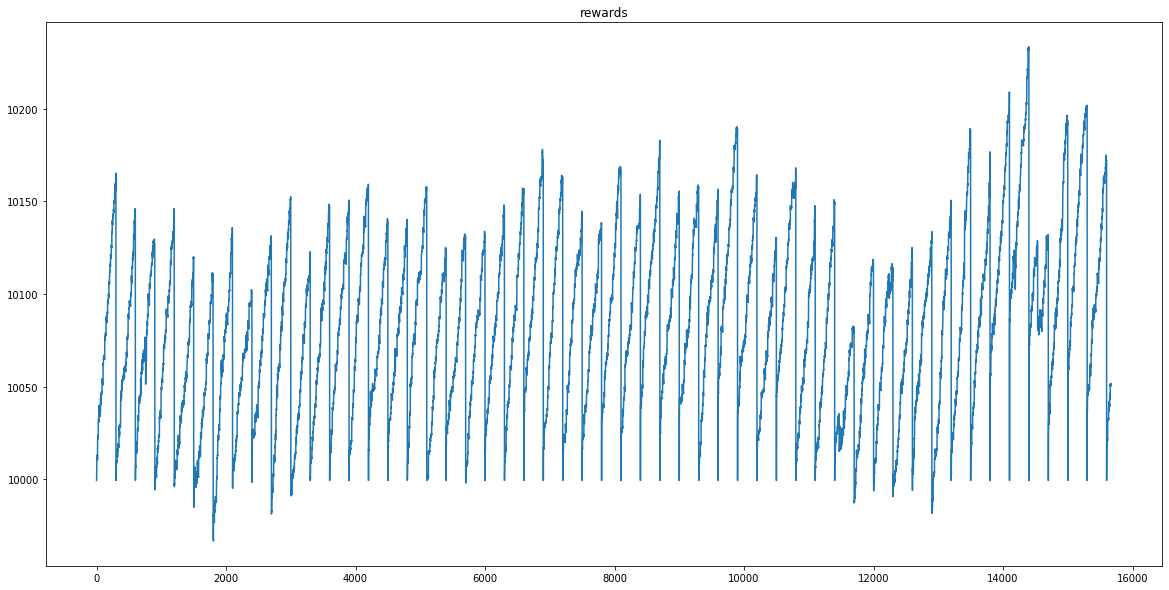

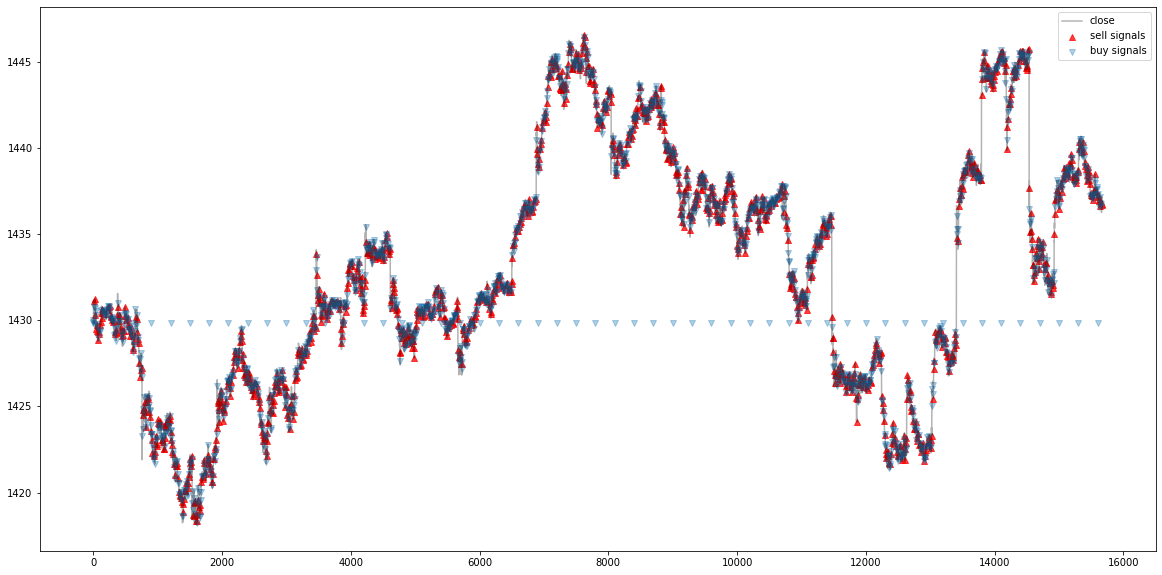

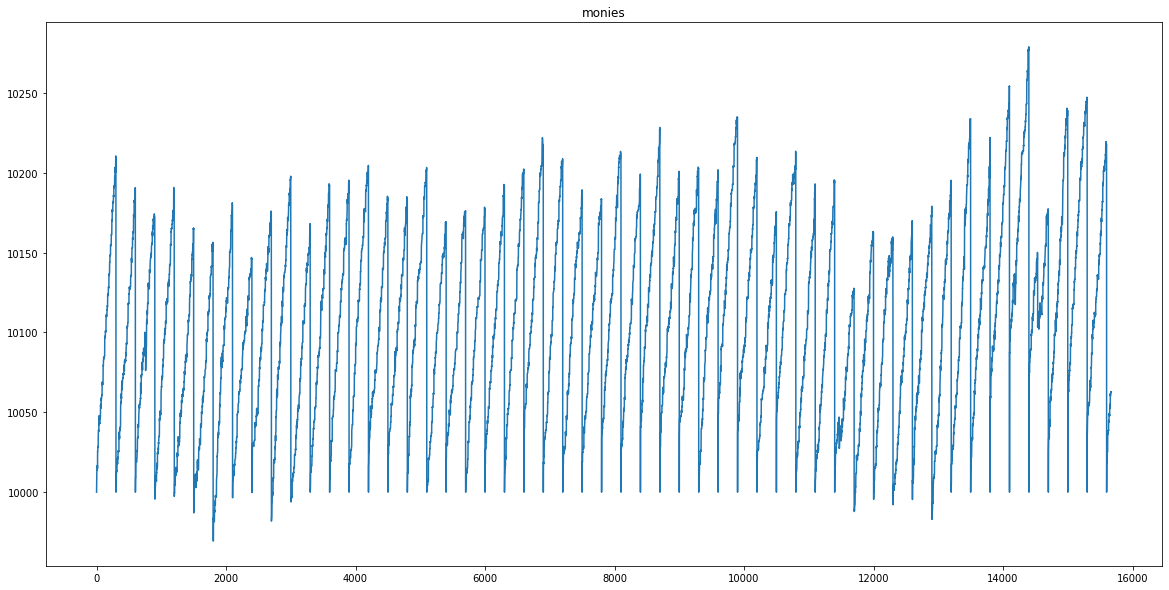

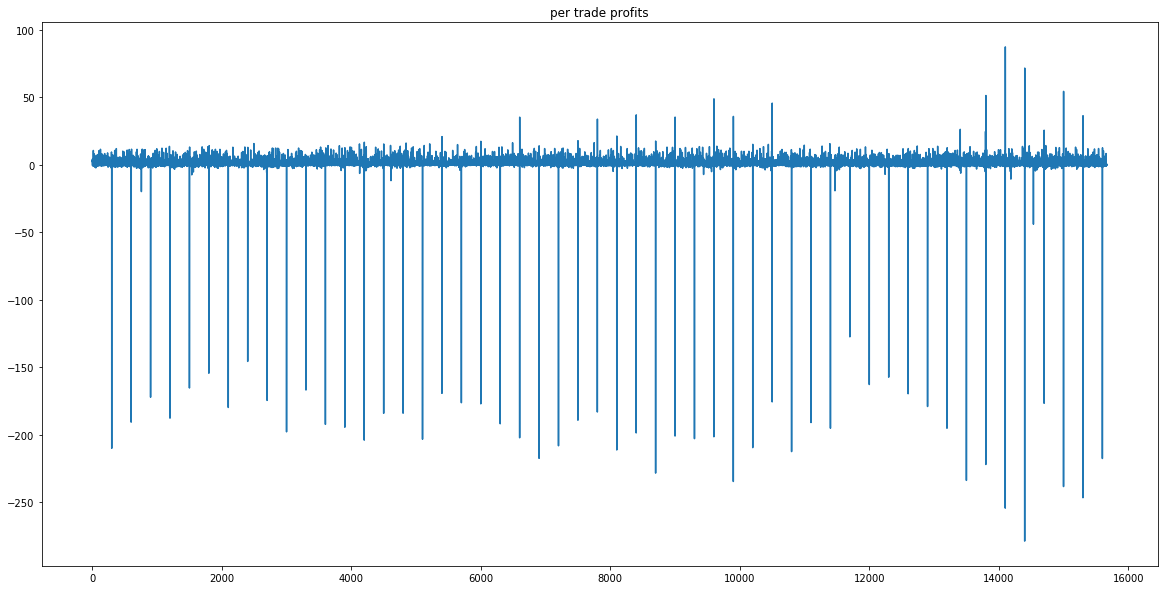

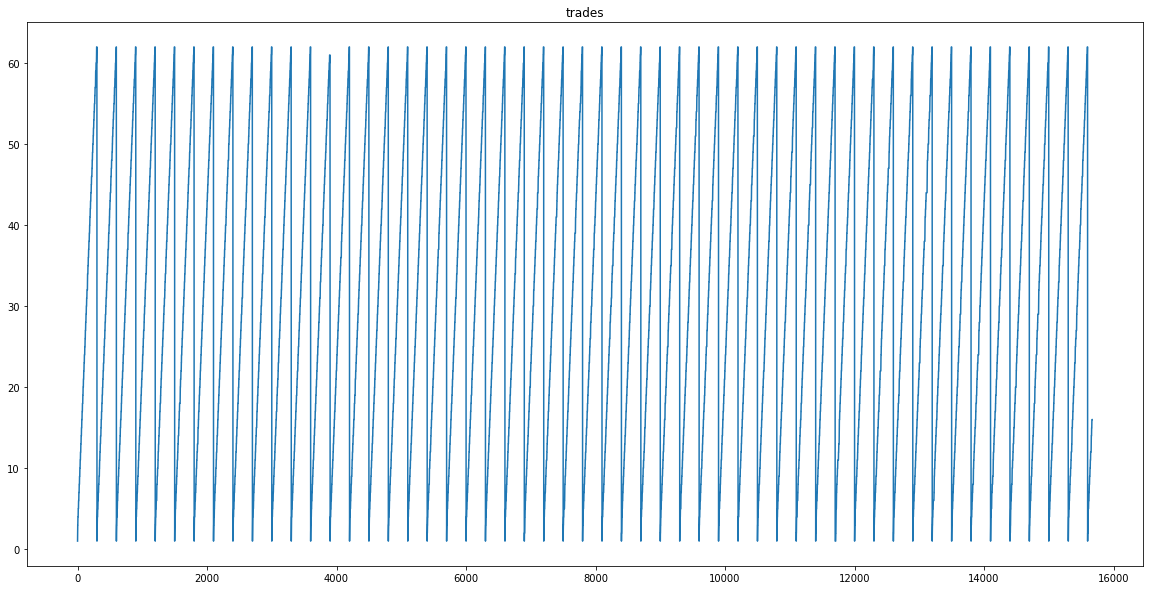

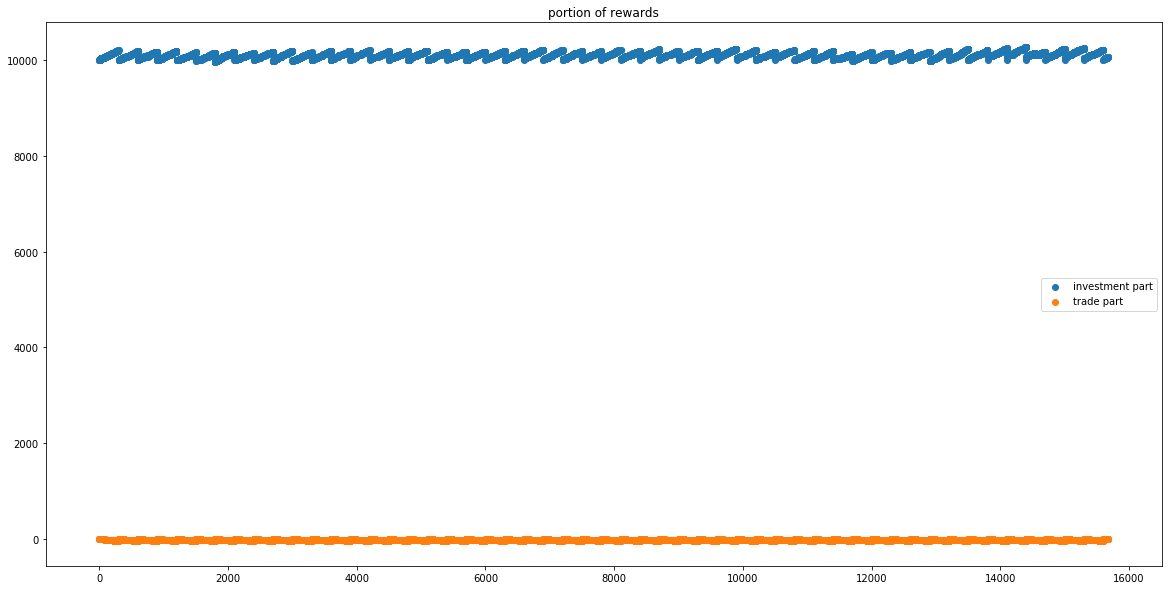

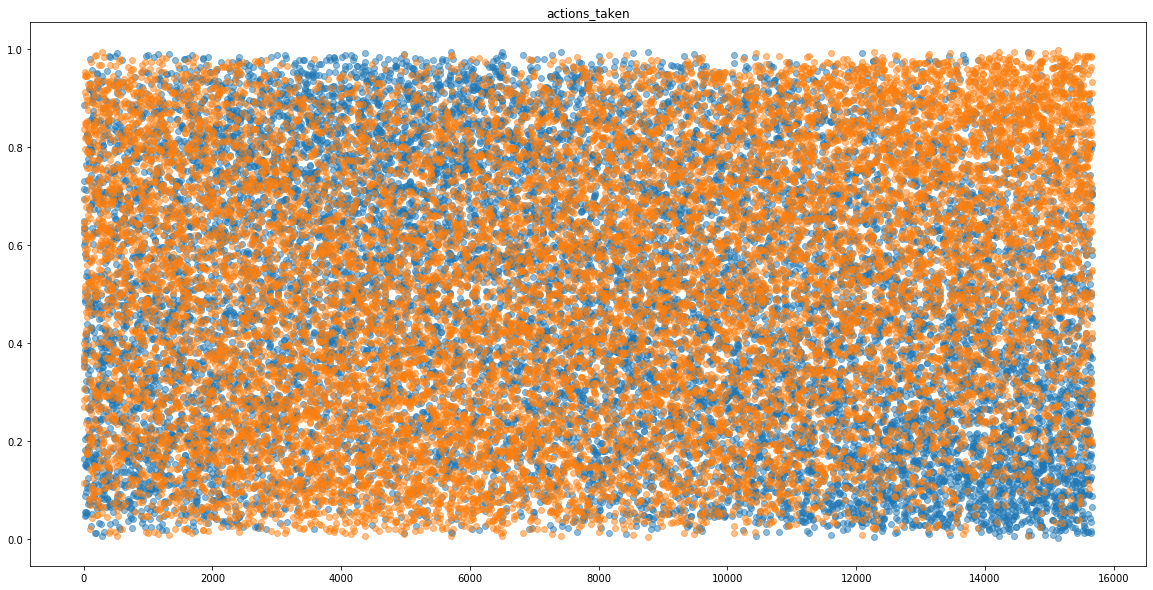

In [349]:
p.plot_rewards()
p.plot_signals()
p.plot_monies()
p.plot_profits()
p.plot_trades()
p.plot_comparison()
p.plot_actions()